In [1]:
import numpy as np
from pygmid import Lookup as lk
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import scipy.constants as sc

# Load technology data
NCH = lk('../../sky130_lookup/simulation/nfet_01v8.mat')
PCH = lk('../../sky130_lookup/simulation/pfet_01v8.mat')

In [2]:
# =================
# FDDA DESIGN SPECS
# =================
VDD = 1.8                                 # Supply Voltage (V)
CL  = 0.25e-12                            # Load Capacitance (F)
Vicm_spec = (0.8, 1.0)                    # Input Common Mode Range (V)
Gain_dc_spec_dB = 72                      # DC Gain (dB)
GBW_spec = 48e6                           # Gain Bandwidth (Hz)
PM_spec = 56                              # Phase Margin (degrees)
SR_spec = 6.6e6                           # Slew Rate (V/s)
CMRR_spec_dB = 120                        # Common Mode Rejection Ratio (dB)
PSRR_spec_dB = 68                         # Power Supply Rejection Ratio (dB)
noise_spec = 0.27e-6                      # Input Referred Noise (V/√Hz)
Power_spec = 180e-6                       # Power Consumption (W)
Area_spec = 42800e-12                     # Area (m^2)

Gain_dc_spec = 10**(Gain_dc_spec_dB/20)   # Convert dB to V/V
CMRR_spec = 10**(CMRR_spec_dB/20)         # Convert dB to V/V
PSRR_spec = 10**(PSRR_spec_dB/20)         # Convert dB to V/V

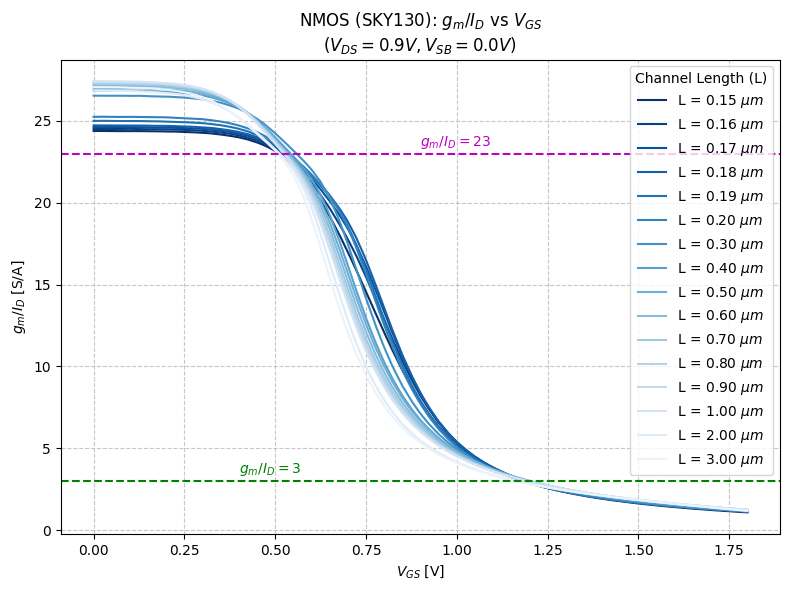

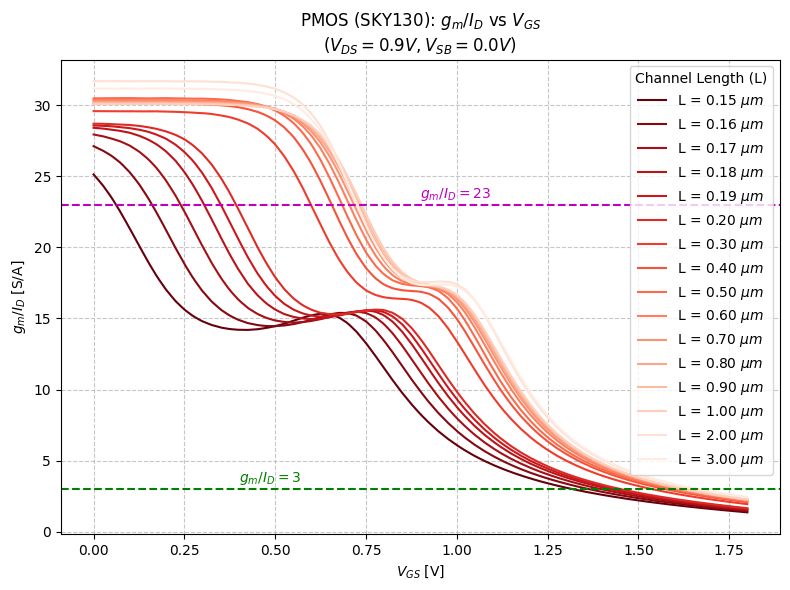

In [3]:
# ==============================
# NMOS & PMOS gm/ID VS VGS PLOTS
# ==============================
# Define Sweep Parameters
VGS_sweep = np.linspace(0, VDD, 200) 
VDS_const = VDD/2  # Set VDS to mid-rail
VSB_const = 0.0  # Source-Bulk voltage

# Plotting Function
def plot_gmid_vs_vgs(device_data, device_name, color_map):
    plt.figure(figsize=(8, 6))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', vgs=VGS_sweep, VDS=VDS_const, VSB=VSB_const, L=L_val)
        
        # Plotting
        plt.plot(VGS_sweep, gm_ID, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(f'{device_name}: $g_m/I_D$ vs $V_{{GS}}$\n($V_{{DS}}={VDS_const}V, V_{{SB}}={VSB_const}V$)')
    plt.xlabel('$V_{GS}$ [V]')
    plt.ylabel('$g_m/I_D$ [S/A]')

    # Upper bound for gm/ID axis
    plt.axhline(y=23, color='m', linestyle='--')
    plt.text(0.9, 23.5, '$g_m/I_D = 23$', color='m')
    # Lower bound for gm/ID axis
    plt.axhline(y=3, color='g', linestyle='--')
    plt.text(0.4, 3.5, '$g_m/I_D = 3$', color='g')

    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_gmid_vs_vgs(NCH, "NMOS (SKY130)", plt.cm.Blues_r)
plot_gmid_vs_vgs(PCH, "PMOS (SKY130)", plt.cm.Reds_r)

In [4]:
# ==================================
# FDDA REFERENCE SIMULATION READINGS
# ==================================
V_B1 = 0.77600       # V
V_B2 = 0.66566       # V
V_B3 = 0.89881       # V
V_B4 = 0.57924       # V
V_CMFB = 0.76174     # V

V_A = 1.59950        # V
V_B = 0.24871        # V
V_C = 1.17100        # V
Vout_DC = 0.99599    # V

I_T = 22.125e-6      # A
I_X = 4.1591e-6      # A

gm_ID_1 = 17.14696   # S/A
gm_ID_2 = 17.85320   # S/A
gm_ID_3 = 18.03487   # S/A
gm_ID_4 = 19.70470   # S/A
gm_ID_5 = 15.95002   # S/A
gm_ID_6 = 16.66659   # S/A

In [5]:
# =======================================
# INPUT DESIGN PARAMETERS FOR FDDA SIZING
# =======================================
# gm_ID_1 = 20   # S/A
# gm_ID_2 = 20   # S/A
# gm_ID_3 = 20   # S/A
# gm_ID_4 = 20   # S/A
# gm_ID_5 = 20   # S/A
# gm_ID_6 = 20   # S/A

L_1 = 1        # um
L_2 = 1        # um
L_3 = 1        # um
L_4 = 1        # um
L_5 = 1        # um
L_6 = 1        # um

# I_T = 20e-3    # A
# I_X = 20e-3    # A

# V_A = 1.4      # V
# V_B = 0.4      # V
# V_C = 1.4      # V
# Vout_DC = 0.9  # V

Vds_1 = V_C - V_B
Vds_2 = VDD - V_A
Vds_3 = V_A - Vout_DC
Vds_4 = Vout_DC - V_B
Vds_5 = V_B
Vds_6 = VDD - V_C

freq = 1e3        # Frequency at which CMRR, PSRR, and noise is calculated (Hz)
temp = 298        # Temperature (K)
k = sc.Boltzmann  # Boltzmann's constant (J/K)

In [6]:
# ================
# GAIN CALCULATION
# ================
gm_2 = gm_ID_2 * I_X
gm_3 = gm_ID_3 * I_X
gds_2 = gm_2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
gds_3 = gm_3 / PCH.lookup('GM_GDS', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Rout_A = (1 / gds_3) + (1 / gds_2) + (gm_3 * (1 / gds_3) * (1 / gds_2))
print(f"Rout_A: {Rout_A/1e6:.2f} MΩ")

gm_4 = gm_ID_4 * I_X
gm_5 = gm_ID_5 * (I_X + I_T)
gm_1 = gm_ID_1 * (I_T / 2)
gds_4 = gm_4 / NCH.lookup('GM_GDS', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
gds_5 = gm_5 / NCH.lookup('GM_GDS', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
gds_1 = gm_1 / PCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Rparr_dm = 1 / (gds_5 + (2 * gds_1))
Rout_B_dm = (1 / gds_4) + Rparr_dm + (gm_4 * (1 / gds_4) * Rparr_dm)
print(f"Rout_B_dm: {Rout_B_dm/1e6:.2f} MΩ")

Gm_dm = gm_1
print(f"Gm_dm: {Gm_dm*1e6:.2f} µS")

Rout_dm = (Rout_A * Rout_B_dm) / (Rout_A + Rout_B_dm)
print(f"Rout_dm: {Rout_dm/1e6:.2f} MΩ")

Gain_dc_calc = Gm_dm * Rout_dm
print(f"Gain_dc_calc_dB: {20*np.log10(Gain_dc_calc):.2f} dB")

Rout_A: 658.23 MΩ
Rout_B_dm: 26.58 MΩ
Gm_dm: 189.69 µS
Rout_dm: 25.55 MΩ
Gain_dc_calc_dB: 73.71 dB


In [7]:
# ================================
# OUTPUT VOLTAGE SWING CALCULATION
# ================================
Vgs_4 = NCH.lookupVGS(GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
Vth_4 = NCH.lookup('VT', VGS=Vgs_4, VDS=Vds_4, VSB=0, L=L_4)
Vov_4 = Vgs_4 - Vth_4
Vgs_5 = NCH.lookupVGS(GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
Vth_5 = NCH.lookup('VT', VGS=Vgs_5, VDS=Vds_5, VSB=0, L=L_5)
Vov_5 = Vgs_5 - Vth_5
V_OP_min = abs(Vov_4) + abs(Vov_5)
print(f"V_OP_min: {V_OP_min:.2f} V")

Vgs_3 = PCH.lookupVGS(GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Vth_3 = PCH.lookup('VT', VGS=Vgs_3, VDS=Vds_3, VSB=0, L=L_3)
Vov_3 = Vgs_3 - Vth_3
Vgs_2 = PCH.lookupVGS(GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
Vth_2 = PCH.lookup('VT', VGS=Vgs_2, VDS=Vds_2, VSB=0, L=L_2)
Vov_2 = Vgs_2 - Vth_2
V_OP_max = VDD - abs(Vov_3) - abs(Vov_2)
print(f"V_OP_max: {V_OP_max:.2f} V")

V_OP_swing = V_OP_max - V_OP_min
print(f"V_OP_swing: {V_OP_swing:.2f} V")
Vout_swing_calc = 2 * V_OP_swing
print(f"Vout_swing_calc: {Vout_swing_calc:.2f} V")

V_OP_min: 0.10 V
V_OP_max: 1.49 V
V_OP_swing: 1.39 V
Vout_swing_calc: 2.77 V


In [8]:
# ==================================
# GAIN-BANDWIDTH PRODUCT CALCULATION
# ==================================
Cdd_3 = gm_3 / PCH.lookup('GM_CDD', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
Cdd_4 = gm_4 / NCH.lookup('GM_CDD', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
C_load = (2 * CL) + Cdd_3 + Cdd_4
print(f"C_load: {C_load*1e15:.2f} fF")

GBW_rads = Gm_dm / C_load
GBW_calc = GBW_rads / (2 * np.pi)
print(f"GBW_calc: {GBW_calc/1e6:.2f} MHz")

C_load: 725.12 fF
GBW_calc: 41.63 MHz


In [9]:
# ========================
# PHASE MARGIN CALCULATION
# ========================
Rfold = 1 / (gm_4 + gds_5 + (2 * gds_1))
print(f"Rfold: {Rfold/1e3:.2f} kΩ")

Css_4 = gm_4 / NCH.lookup('GM_CSS', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
Cdd_1 = gm_1 / PCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Cdd_5 = gm_5 / NCH.lookup('GM_CDD', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
Cfold = Css_4 + Cdd_5 + (2 * Cdd_1)
print(f"Cfold: {Cfold*1e15:.2f} fF")

non_dom_pole = 1 / (Rfold * Cfold)
print(f"Non-dominant Pole: {non_dom_pole/(2 * np.pi * 1e6):.2f} MHz")

PM_calc = 90 - (np.arctan(GBW_rads / non_dom_pole) * (180 / np.pi))
print(f"PM_calc: {PM_calc:.2f} degrees")

Rfold: 11.32 kΩ
Cfold: 229.71 fF
Non-dominant Pole: 61.23 MHz
PM_calc: 55.79 degrees


In [10]:
# =====================
# SLEW RATE CALCULATION
# =====================
SR_calc = I_T / C_load
print(f"SR_calc: {SR_calc/1e6:.2f} V/µs")

SR_calc: 30.51 V/µs


In [11]:
# =================
# POWER CALCULATION
# =================
Power_calc = 4 * (I_X + I_T) * VDD
print(f"Power_calc: {Power_calc*1e6:.2f} µW")

Power_calc: 189.25 µW


In [12]:
# ===================================
# INPUT COMMON MODE RANGE CALCULATION
# ===================================
Vgs_1 = PCH.lookupVGS(GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
Vth_1 = PCH.lookup('VT', VGS=Vgs_1, VDS=Vds_1, VSB=0, L=L_1)
Vicm_min = V_B - abs(Vth_1)
print(f"Vicm_min: {Vicm_min:.2f} V")

Vgs_6 = PCH.lookupVGS(GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Vth_6 = PCH.lookup('VT', VGS=Vgs_6, VDS=Vds_6, VSB=0, L=L_6)
Vov_6 = Vgs_6 - Vth_6
Vicm_max = VDD - Vgs_1 - abs(Vov_6)
print(f"Vicm_max: {Vicm_max:.2f} V")

Vicm_min: -0.77 V
Vicm_max: 0.81 V


In [13]:
# ================
# CMRR CALCULATION
# ================
gm_6 = gm_ID_6 * I_T
gds_6 = gm_6 / PCH.lookup('GM_GDS', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Cdd_6 = gm_6 / PCH.lookup('GM_CDD', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)
Css_1 = gm_1 / PCH.lookup('GM_CSS', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
C_tail = Cdd_6 + (2 * Css_1)
Z_tail = np.abs(1 / (gds_6 + (1j * 2 * np.pi * freq * C_tail)))
print(f"Z_tail: {Z_tail/1e6:.2f} MΩ")

Gm_cm = 1 / Z_tail
print(f"Gm_cm: {Gm_cm*1e6:.2f} µS")

Rparr_cm = 1 / (gds_5 + (1 / ((0.5 / gds_1) + ((1 / gds_6) * (1 + (gm_1 / gds_1))))))
Rout_B_cm = (1 / gds_4) + ((1 + (gm_4 / gds_4)) * Rparr_cm)
Rout_cm = (Rout_A * Rout_B_cm) / (Rout_A + Rout_B_cm)
Zout_cm = abs(1 / ((1 / Rout_cm) + (1j * 2 * np.pi * freq * C_load)))
print(f"Zout_cm: {Zout_cm/1e6:.2f} MΩ")

Gain_cm_open = Gm_cm * Zout_cm
print(f"Gain_cm_open_dB: {20*np.log10(Gain_cm_open):.2f} dB")

###################################
Lgain_cmfb = abs((gm_2 * gm_4) / ((1j * 2 * np.pi * freq * C_load) * gm_2)) # Change gm values later (dummies used)
###################################
Gain_cm_calc = Gain_cm_open / (1 + Lgain_cmfb)
print(f"Gain_cm_calc_dB: {20*np.log10(Gain_cm_calc):.2f} dB")

Zout_dm = abs(1 / ((1 / Rout_dm) + (1j * 2 * np.pi * freq * C_load)))
Gain_dm_calc = Gm_dm * Zout_dm
print(f"Gain_dm_calc_dB: {20*np.log10(Gain_dm_calc):.2f} dB")

CMRR_calc = Gain_dm_calc / Gain_cm_calc
print(f"CMRR_calc_dB: {20*np.log10(CMRR_calc):.2f} dB")

Z_tail: 1.11 MΩ
Gm_cm: 0.90 µS
Zout_cm: 28.13 MΩ
Gain_cm_open_dB: 28.05 dB
Gain_cm_calc_dB: -57.05 dB
Gain_dm_calc_dB: 73.65 dB
CMRR_calc_dB: 130.70 dB


In [14]:
# ================================
# INPUT REFERRED NOISE CALCULATION
# ================================
gamma_1 = PCH.gamma(GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
noise_1 = 4 * (((4 * k * temp * gamma_1) / gm_1) + (PCH.lookup('SFL_GM', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1) / gm_1 / freq))
print(f"noise_1: {np.sqrt(noise_1)*1e6:.2f} µV/√Hz")

gamma_5 = NCH.gamma(GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
noise_5 = 2 * (((4 * k * temp * gamma_5 * gm_5) / (gm_1 ** 2)) + ((NCH.lookup('SFL_GM', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5) / freq) * (gm_5 / (gm_1 ** 2))))
print(f"noise_5: {np.sqrt(noise_5)*1e6:.2f} µV/√Hz")

gamma_2 = PCH.gamma(GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
noise_2 = 2 * (((4 * k * temp * gamma_2 * gm_2) / (gm_1 ** 2)) + ((PCH.lookup('SFL_GM', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2) / freq) * (gm_2 / (gm_1 ** 2))))
print(f"noise_2: {np.sqrt(noise_2)*1e6:.2f} µV/√Hz")

noise_calc = np.sqrt(noise_1 + noise_5 + noise_2)
print(f"noise_calc: {noise_calc*1e6:.3f} µV/√Hz")

noise_1: 0.07 µV/√Hz
noise_5: 0.33 µV/√Hz
noise_2: 0.02 µV/√Hz
noise_calc: 0.338 µV/√Hz


In [15]:
# # ================
# # PSRR CALCULATION
# # ================
# gm_mirr = (gm_4 / (gm_4 + gds_5)) * (gm_6 + (((2 * gm_1) - gm_6 + (2 * gds_1)) / (1 + (2 * gm_1 / gds_6) + (2 * gds_1))))
# gm_dir = gm_2 + ((gm_3 - gm_2) / (1 + (gm_3 / gds_2)))
# Gm_ps = gm_mirr + gm_dir
# print(f"Gm_ps: {Gm_ps*1e6:.2f} µS")

# Gain_ps_calc = Gm_ps * Zout_cm
# print(f"Gain_ps_calc_dB: {20*np.log10(Gain_ps_calc):.2f} dB")

# PSRR_calc = Gain_dm_calc / Gain_ps_calc
# print(f"PSRR_calc_dB: {20*np.log10(PSRR_calc):.2f} dB")

In [16]:
# =====================================
# CALCUATE W SIZING FOR EACH TRANSISTOR
# =====================================
JD_1 = PCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=Vds_1, VSB=0, L=L_1)
JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vds_2, VSB=0, L=L_2)
JD_3 = PCH.lookup('ID_W', GM_ID=gm_ID_3, VDS=Vds_3, VSB=0, L=L_3)
JD_4 = NCH.lookup('ID_W', GM_ID=gm_ID_4, VDS=Vds_4, VSB=0, L=L_4)
JD_5 = NCH.lookup('ID_W', GM_ID=gm_ID_5, VDS=Vds_5, VSB=0, L=L_5)
JD_6 = PCH.lookup('ID_W', GM_ID=gm_ID_6, VDS=Vds_6, VSB=0, L=L_6)

W_1 = (I_T / 2) / JD_1
W_2 = I_X / JD_2
W_3 = I_X / JD_3
W_4 = I_X / JD_4
W_5 = (I_X + I_T) / JD_5
W_6 = I_T / JD_6

print(f"W_1: {W_1:.2f} µm")
print(f"W_2: {W_2:.2f} µm") 
print(f"W_3: {W_3:.2f} µm")
print(f"W_4: {W_4:.2f} µm")
print(f"W_5: {W_5:.2f} µm")
print(f"W_6: {W_6:.2f} µm")

W_1: 182.69 µm
W_2: 361.47 µm
W_3: 426.45 µm
W_4: 9.54 µm
W_5: 21.98 µm
W_6: 198.08 µm


In [17]:
gm_ID = {
    'gm_ID_1': 17.14696,   # S/A
    'gm_ID_2': 17.85320,   # S/A
    'gm_ID_3': 18.03487,   # S/A
    'gm_ID_4': 19.70470,   # S/A
    'gm_ID_5': 15.95002,   # S/A
    'gm_ID_6': 16.66659    # S/A
}

Vds = {
    'Vds_1': V_C - V_B,
    'Vds_2': VDD - V_A,
    'Vds_3': V_A - Vout_DC,
    'Vds_4': Vout_DC - V_B,
    'Vds_5': V_B,
    'Vds_6': VDD - V_C
}

L = {
    'L_1': 1,  # um
    'L_2': 1,  # um
    'L_3': 1,  # um
    'L_4': 1,  # um
    'L_5': 1,  # um
    'L_6': 1,  # um
    'L_7': 1,  # um
    'L_8': 1   # um
}

ID = {
    'ID_1': I_T / 2,
    'ID_2': I_X,
    'ID_3': I_X,
    'ID_4': I_X,
    'ID_5': I_X + I_T,
    'ID_6': I_T,
    'ID_7': (I_X + I_T) / 2,
    'ID_8': I_X + I_T
}

In [18]:
# Function to calculate W for each transistor based on gm_ID, Vds, L, and ID
def get_Widths(gm_ID, Vds, L, ID):

    # LUT readout for CMFB circuit transistors (M7 and M8)
    Vds['Vds_8'] = PCH.lookupVGS(GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2'])
    Vds['Vds_7'] = VDD - Vds['Vds_8'] - Vds['Vds_5']

    gm_ID['gm_ID_7'] = NCH.lookup('GM_ID', VGS=Vds['Vds_4'], VDS=Vds['Vds_7'], VSB=0, L=L['L_7'])
    gm_ID['gm_ID_8'] = PCH.lookup('GM_ID', VGS=Vds['Vds_8'], VDS=Vds['Vds_8'], VSB=0, L=L['L_8'])

    # Read the current density (A/µm) from the LUTs
    JD_1 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1'])
    JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2'])
    JD_3 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=0, L=L['L_3'])
    JD_4 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=0, L=L['L_4'])
    JD_5 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5'])
    JD_6 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=0, L=L['L_6'])
    JD_7 = NCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_7'], VDS=Vds['Vds_7'], VSB=0, L=L['L_7'])
    JD_8 = PCH.lookup('ID_W', GM_ID=gm_ID['gm_ID_8'], VDS=Vds['Vds_8'], VSB=0, L=L['L_8'])

    # Calculate W for each transistor
    W = {
        'W_1': ID['ID_1'] / JD_1,
        'W_2': ID['ID_2'] / JD_2,
        'W_3': ID['ID_3'] / JD_3,
        'W_4': ID['ID_4'] / JD_4,
        'W_5': ID['ID_5'] / JD_5,
        'W_6': ID['ID_6'] / JD_6,
        'W_7': ID['ID_7'] / JD_7,
        'W_8': ID['ID_8'] / JD_8
    }
    return W

In [19]:
# Function to calculate all the required variables for each transistor based on gm_ID, Vds, L, and ID
def get_specVars(gm_ID, Vds, L, ID):

    W = get_Widths(gm_ID, Vds, L, ID)

    # Return "None" if any one of W is none
    if any(w is None for w in W.values()):
        return None, None, None, None, None, None, None
    else:

        # Calculate transconductance (S) for each transistor
        gm = {
            'gm_1': gm_ID['gm_ID_1'] * ID['ID_1'],
            'gm_2': gm_ID['gm_ID_2'] * ID['ID_2'],
            'gm_3': gm_ID['gm_ID_3'] * ID['ID_3'],
            'gm_4': gm_ID['gm_ID_4'] * ID['ID_4'],
            'gm_5': gm_ID['gm_ID_5'] * ID['ID_5'],
            'gm_6': gm_ID['gm_ID_6'] * ID['ID_6'],
            'gm_7': gm_ID['gm_ID_7'] * ID['ID_7'],
            'gm_8': gm_ID['gm_ID_8'] * ID['ID_8']
        }

        # Read the drain conductance (S) from the LUTs
        gds = {
            'gds_1': gm['gm_1'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'gds_2': gm['gm_2'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2']),
            'gds_3': gm['gm_3'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=0, L=L['L_3']),
            'gds_4': gm['gm_4'] / NCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=0, L=L['L_4']),
            'gds_5': gm['gm_5'] / NCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5']),
            'gds_6': gm['gm_6'] / PCH.lookup('GM_GDS', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=0, L=L['L_6'])
        }

        # Read the capacitances (F) from the LUTs
        C = {
            'Cdd_1': gm['gm_1'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'Cdd_3': gm['gm_3'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=0, L=L['L_3']),
            'Cdd_4': gm['gm_4'] / NCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=0, L=L['L_4']),
            'Cdd_5': gm['gm_5'] / NCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5']),
            'Cdd_6': gm['gm_6'] / PCH.lookup('GM_CDD', GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=0, L=L['L_6']),

            'Css_1': gm['gm_1'] / PCH.lookup('GM_CSS', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'Css_4': gm['gm_4'] / NCH.lookup('GM_CSS', GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=0, L=L['L_4'])
        }

        # Read the gate-source voltage (V) from the LUTs
        Vgs = {
            'Vgs_1': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'Vgs_2': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2']),
            'Vgs_3': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_3'], VDS=Vds['Vds_3'], VSB=0, L=L['L_3']),
            'Vgs_4': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_4'], VDS=Vds['Vds_4'], VSB=0, L=L['L_4']),
            'Vgs_5': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5']),
            'Vgs_6': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_6'], VDS=Vds['Vds_6'], VSB=0, L=L['L_6']),
            'Vgs_7': NCH.lookupVGS(GM_ID=gm_ID['gm_ID_7'], VDS=Vds['Vds_7'], VSB=0, L=L['L_7']),
            'Vgs_8': PCH.lookupVGS(GM_ID=gm_ID['gm_ID_8'], VDS=Vds['Vds_8'], VSB=0, L=L['L_8'])
        }

        # Read the gamma values from the LUTs
        gamma = {
            'gamma_1': PCH.gamma(GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'gamma_2': PCH.gamma(GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2']),
            'gamma_5': NCH.gamma(GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5'])
        }
        
        # Read the flicker noise (nA/√Hz) from the LUTs
        flicker = {
            'flicker_1': PCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_1'], VDS=Vds['Vds_1'], VSB=0, L=L['L_1']),
            'flicker_2': PCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_2'], VDS=Vds['Vds_2'], VSB=0, L=L['L_2']),
            'flicker_5': NCH.lookup('SFL_GM', GM_ID=gm_ID['gm_ID_5'], VDS=Vds['Vds_5'], VSB=0, L=L['L_5'])
        }

    return W, gm, gds, C, Vgs, gamma, flicker

In [20]:
# Function to calculate the feasible range of design variables
def get_feasReion(gm_ID_range, L_discrete_values):

    # Range of gm/ID values to consider for the design
    gm_ID_min = gm_ID_range[0]
    gm_ID_max = gm_ID_range[1]

    # Minimum current calculations based on slew rate
    IT_min = SR_spec * CL
    IX_min = IT_min * 0.01 # Assuming IX is at least 1% of IT

    # Maximum current calculations based on power budget
    IT_max = (Power_spec / VDD / 4) - IX_min
    IX_max = (Power_spec / VDD / 4) - IT_min

    L_available = L_discrete_values
    n_L_values = len(L_available)

    return gm_ID_min, gm_ID_max, IT_min, IT_max, IX_min, IX_max, L_available, n_L_values

In [21]:
W, gm, gds, C, Vgs, gamma, flicker = get_specVars(gm_ID, Vds, L, ID)

# ===================
# DC Gain Calculation
# ===================
Gm_dm = gm['gm_1']
Rout_A = (1 / gds['gds_3']) + (1 / gds['gds_2']) + (gm['gm_3'] * (1 / gds['gds_3']) * (1 / gds['gds_2']))
Rparr_dm = 1 / (gds['gds_5'] + (2 * gds['gds_1']))
Rout_B_dm = (1 / gds['gds_4']) + Rparr_dm + (gm['gm_4'] * (1 / gds['gds_4']) * Rparr_dm)
Rout_dm = (Rout_A * Rout_B_dm) / (Rout_A + Rout_B_dm)
Gain_dc_calc = Gm_dm * Rout_dm

print(f"Gain_dc_calc_dB: {20*np.log10(Gain_dc_calc):.2f} dB")

# ==================================
# Gain-Bandwidth Product Calculation
# ==================================
C_load = (2 * CL) + C['Cdd_3'] + C['Cdd_4']
GBW_rads = Gm_dm / C_load
GBW_calc = GBW_rads / (2 * np.pi)

print(f"GBW_calc: {GBW_calc/1e6:.2f} MHz")

# ========================
# Phase Margin Calculation
# ========================
Rfold = 1 / (gm['gm_4'] + gds['gds_5'] + (2 * gds['gds_1']))
Cfold = C['Css_4'] + C['Cdd_5'] + (2 * C['Cdd_1'])

non_dom_pole = 1 / (Rfold * Cfold)
PM_calc = 90 - (np.arctan(GBW_rads / non_dom_pole) * (180 / np.pi))

print(f"PM_calc: {PM_calc:.2f} degrees")

# =====================
# Slew Rate Calculation
# =====================
SR_calc = ID['ID_6'] / C_load

print(f"SR_calc: {SR_calc/1e6:.2f} V/µs")

# =================
# Power Calculation
# =================
Power_calc = 4 * ID['ID_5'] * VDD

print(f"Power_calc: {Power_calc*1e6:.2f} µW")

# ================================
# Input Referred Noise Calculation
# ================================
noise_1 = 4 * (((4 * k * temp * gamma['gamma_1']) / gm['gm_1']) + (flicker['flicker_1'] / gm['gm_1'] / freq))
noise_5 = 2 * (((4 * k * temp * gamma['gamma_5'] * gm['gm_5']) / (gm['gm_1'] ** 2)) + ((flicker['flicker_5'] / freq) * (gm['gm_5'] / (gm['gm_1'] ** 2))))
noise_2 = 2 * (((4 * k * temp * gamma['gamma_2'] * gm['gm_2']) / (gm['gm_1'] ** 2)) + ((flicker['flicker_2'] / freq) * (gm['gm_2'] / (gm['gm_1'] ** 2))))
noise_calc = np.sqrt(noise_1 + noise_5 + noise_2)

print(f"noise_calc: {noise_calc*1e6:.3f} µV/√Hz")

# ================
# CMRR Calculation
# ================
C_tail = C['Cdd_6'] + (2 * C['Css_1'])
Z_tail = np.abs(1 / (gds['gds_6'] + (1j * 2 * np.pi * freq * C_tail)))
Gm_cm = 1 / Z_tail

Rparr_cm = 1 / (gds['gds_5'] + (1 / ((0.5 / gds['gds_1']) + ((1 / gds['gds_6']) * (1 + (gm['gm_1'] / gds['gds_1']))))))
Rout_B_cm = (1 / gds['gds_4']) + ((1 + (gm['gm_4'] / gds['gds_4'])) * Rparr_cm)
Rout_cm = (Rout_A * Rout_B_cm) / (Rout_A + Rout_B_cm)
Zout_cm = abs(1 / ((1 / Rout_cm) + (1j * 2 * np.pi * freq * C_load)))
Gain_cm_open = Gm_cm * Zout_cm

Lgain_cmfb = abs((gm['gm_2'] * gm['gm_7']) / ((1j * 2 * np.pi * freq * C_load) * gm['gm_8']))
Gain_cm_calc = Gain_cm_open / (1 + Lgain_cmfb)

Zout_dm = abs(1 / ((1 / Rout_dm) + (1j * 2 * np.pi * freq * C_load)))
Gain_dm_calc = Gm_dm * Zout_dm

CMRR_calc = Gain_dm_calc / Gain_cm_calc

print(f"CMRR_calc_dB: {20*np.log10(CMRR_calc):.2f} dB")

# ================
# Area Calculation
# ================
Area = (4 * W['W_1'] * L['L_1']) \
        + (2 * W['W_2'] * L['L_2']) \
        + (2 * W['W_3'] * L['L_3']) \
        + (2 * W['W_4'] * L['L_4']) \
        + (4 * W['W_5'] * L['L_5']) \
        + (2 * W['W_6'] * L['L_6']) \
        + (4 * W['W_7'] * L['L_7']) \
        + (2 * W['W_8'] * L['L_8'])

print(f"Area: {Area:.2f} µm²")

# ========================
# Bias Voltage Calculation
# ========================
V_B1 = VDD - Vgs['Vgs_6']
V_B2 = Vgs['Vgs_5']
V_B3 = V_B + Vgs['Vgs_4']
V_B4 = V_A - Vgs['Vgs_3']
V_CMFB = VDD - Vgs['Vgs_2']
# print all voltages in a single print statement
print(f"V_B1: {V_B1:.2f} V, V_B2: {V_B2:.2f} V, V_B3: {V_B3:.2f} V, V_B4: {V_B4:.2f} V, V_CMFB: {V_CMFB:.2f} V\n")

# Print lengths and widths
for i in range(1, len(W)+1):
    print(f"L_{i}: {L[f'L_{i}']:.2f} µm, W_{i}: {W[f'W_{i}']:.2f} µm")

Gain_dc_calc_dB: 73.71 dB
GBW_calc: 41.63 MHz
PM_calc: 55.79 degrees
SR_calc: 30.51 V/µs
Power_calc: 189.25 µW
noise_calc: 0.338 µV/√Hz
CMRR_calc_dB: 119.70 dB
Area: 7287.29 µm²
V_B1: 0.80 V, V_B2: 0.67 V, V_B3: 0.86 V, V_B4: 0.74 V, V_CMFB: 0.93 V

L_1: 1.00 µm, W_1: 182.69 µm
L_2: 1.00 µm, W_2: 361.47 µm
L_3: 1.00 µm, W_3: 426.45 µm
L_4: 1.00 µm, W_4: 9.54 µm
L_5: 1.00 µm, W_5: 21.98 µm
L_6: 1.00 µm, W_6: 198.08 µm
L_7: 1.00 µm, W_7: 3.76 µm
L_8: 1.00 µm, W_8: 2231.24 µm


In [22]:
ranges = get_feasReion(gm_ID_range=(3, 20), L_discrete_values=[1, 2, 3])
print(
f"gm_ID_min: {ranges[0]:.2f},\n"
f"gm_ID_max: {ranges[1]:.2f},\n"
f"IT_min: {ranges[2]*1e6:.4f} µA,\n"
f"IT_max: {ranges[3]*1e6:.4f} µA,\n"
f"IX_min: {ranges[4]*1e6:.4f} µA,\n"
f"IX_max: {ranges[5]*1e6:.4f} µA,\n"
f"L_available: {ranges[6]},\n"
f"n_L_values: {ranges[7]}"
)

gm_ID_min: 3.00,
gm_ID_max: 20.00,
IT_min: 1.6500 µA,
IT_max: 24.9835 µA,
IX_min: 0.0165 µA,
IX_max: 23.3500 µA,
L_available: [1, 2, 3],
n_L_values: 3
